In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import math


0. Question 0 (0 points).
Create an assignments/ folder in your fork of our class GitHub repository. Include
your code in a (well-documented, commented, clear) assignment01.ipynb file. Scores
for the code-based questions below will be based on your written responses and code.

1. Watts & Strogatz, 1998 (15 points).
The “Watts-Strogatz” model1 is a simple random network model that produces graphs
that have 1) the small world property and 2) high clustering. Reproduce the canonical
figure2 from the original 1998 article, and comment on the key insights from the figure.


In [267]:

def ring_lattice(n: int, k: int) -> nx.Graph:
    """
    k >> ln(n) guarantees a connected graph.

    Parameters
    ----------
    n: int
        Number of nodes in lattice
    k: int
        Degree of nodes in lattice (must be even)

    Returns
    -------
    G: nx.Graph
        Ring lattice with n nodes connected to k neighbors
    
    """

    adj = np.zeros((n, n))      # empty adjacency matrix

    for i in range(1, int(k / 2) + 1):
        adj += np.eye(n, k=i)   # forward neighbors
        adj += np.eye(n, k=n-i) # backward neighbors

    # not needed since edges are undirected
    # adj += np.flip(adj)         # copy to lower triangle
        
    G = nx.from_numpy_array(adj)

    return G


def nth_nearest_clockwise_neighbor(node: int, neighbors: list[int], n: int):
    """
    Gets nth nearest clockwise neighbor in a ring lattice. If n > neighbors, returns the furthest neighbor

    Parameters
    ----------
    node: int
    
    neighbors: list[int]
        List of the nodes neighbors

    n: int
        How far to seek

    Returns
    -------
    nearest: int
    """


    if len(neighbors) == 0:
        return None
    
    neighbors = sorted(neighbors)
    
    over = []
    under = []

    # neighbors less than node require another lap to get to
    for neighbor in neighbors:
        if neighbor > node:
            over.append(neighbor)
        else:
            under.append(neighbor)

    l = over + under

    nearest = l[n] if n < len(l) else l[-1]
    
    return nearest


def rewire_lattice(G: nx.Graph, p: float, laps: int = 0) -> nx.Graph:
    """
    Rewires circular lattice G by iterating over nodes clockwise. For each lap n, picks the
    edge to the nth nearest neighbor and rewires to a random node with probability p. If the 
    randomly chosen edge already exists, then it is skipped.

    Parameters
    ----------
    G: nx.Graph
        Circular lattice graph 

    p: float
        Probability of rewiring edges

    laps: int
        Number of laps to iterate over graph. Defaults to k/2

    Returns
    -------
    G: nx.Graph
        Randomly rewired circular lattice graph

    """
    if laps == 0:
        laps = int(len(G.edges) / 2)

    for lap in range(laps):
        for node in G.nodes:

            # chance of rewiring, continue here for efficiency
            if random.random() > p:
                continue

            neighbors = list(G.neighbors(node))

            # can't rewire if no neighbors
            if len(neighbors) == 0:
                continue

            nearest = nth_nearest_clockwise_neighbor(node, neighbors, lap)

            # remove nodes so no self loops
            random_nodes = list(set(G.nodes) - set([node, nearest]))

            # get a random node
            random_node = random.choice(random_nodes)

            # no multiedges
            if (node, random_node) in G.edges:
                # print(f"picked existing (%d, %d)" % (node, random_node))
                continue

            # rewire
            G.remove_edge(node, nearest)
            G.add_edge(node, random_node)
            # print(f"rewiring (%d, %d) -> (%d, %d)" %(node, nearest, node, random_node))

    return G

In [268]:
data = pd.DataFrame(columns=["p", "L", "C"])

# 20 random realizations of network, normalized by regular lattice
realizations = 20

# ring lattice with n vertices and k edges per vertex
n = 1000
k = 12

# rewire with probability p, varying logarithmically from 0 < p <= 1
probs = np.logspace(-4, 0, 14).tolist()

# regular lattice for normalization
G0 = ring_lattice(n, k)


for p in probs:

    l = []  # shortest path
    c = []  # clustering

    for _ in range(realizations):
        G = ring_lattice(n, k)

        G = rewire_lattice(G, p, int(k/4))  # can't get this to work with k/2

        l.append(nx.average_shortest_path_length(G))
        c.append(nx.average_clustering(G))

    # normalized characteristic path length L(p) / L(0)
    L = np.mean(l) / nx.average_shortest_path_length(G0)

    # normalized clustering coefficient C(p) / C(0)
    C = np.mean(c) / nx.average_clustering(G0)

    data.loc[len(data)] = ({
        "p": p,
        "L": L,
        "C": C
    })


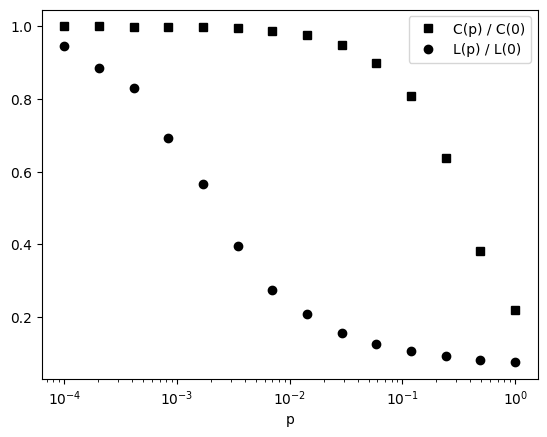

In [270]:
plt.plot(data["p"], data["C"], 'ks', label="C(p) / C(0)")
plt.plot(data["p"], data["L"], 'ko', label="L(p) / L(0)")
plt.xscale("log")
plt.xlabel("p")

plt.legend()

# plt.show()
plt.savefig("output/watts_strogatz_fig1.png")

2. Visualization (15 points).
Download the netscience dataset at this URL: https://tinyurl.com/bd6cwsd4.
As described in the .txt file, this is a coauthorship network of scientists working on
network theory and experiments, compiled by Mark Newman in 2006. Visualize the
largest component of the network (Gephi may be the easiest choice of software, but
you are free to use your favorite), considering the following:

• Degree or other centrality measures

• Edge properties

• Layout

Make good use of color, size, and layout to create a clear, informative visualization.
Describe your approach and comment on your observations (about 5 sentences).
1 Watts, D. & Strogatz, S. Collective dynamics of ‘small-world’ networks. Nature 393, 440–442 (1998).
https://doi.org/10.1038/30918.
2 https://www.nature.com/articles/30918/figures/2
2

In [281]:
def giant_subgraph(G):
    """
    Returns the subgraph of the giant component of G

    Parameters
    ----------
    G: nx.Graph


    Returns
    -------
    giant_subgraph: nx.Graph
        Subgraph of the giant component of G
    """
    giant = sorted(nx.connected_components(G), key=len, reverse=True)[0]
    giant_subgraph = nx.subgraph(G, giant)
    
    return giant_subgraph

[34, 27, 27, 21, 19, 18, 17, 16, 15, 15, 15, 14, 14, 14, 14, 12, 12, 12, 12, 12, 12, 12, 12, 11, 11, 11, 11, 11, 10, 10, 10, 10, 10, 10, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

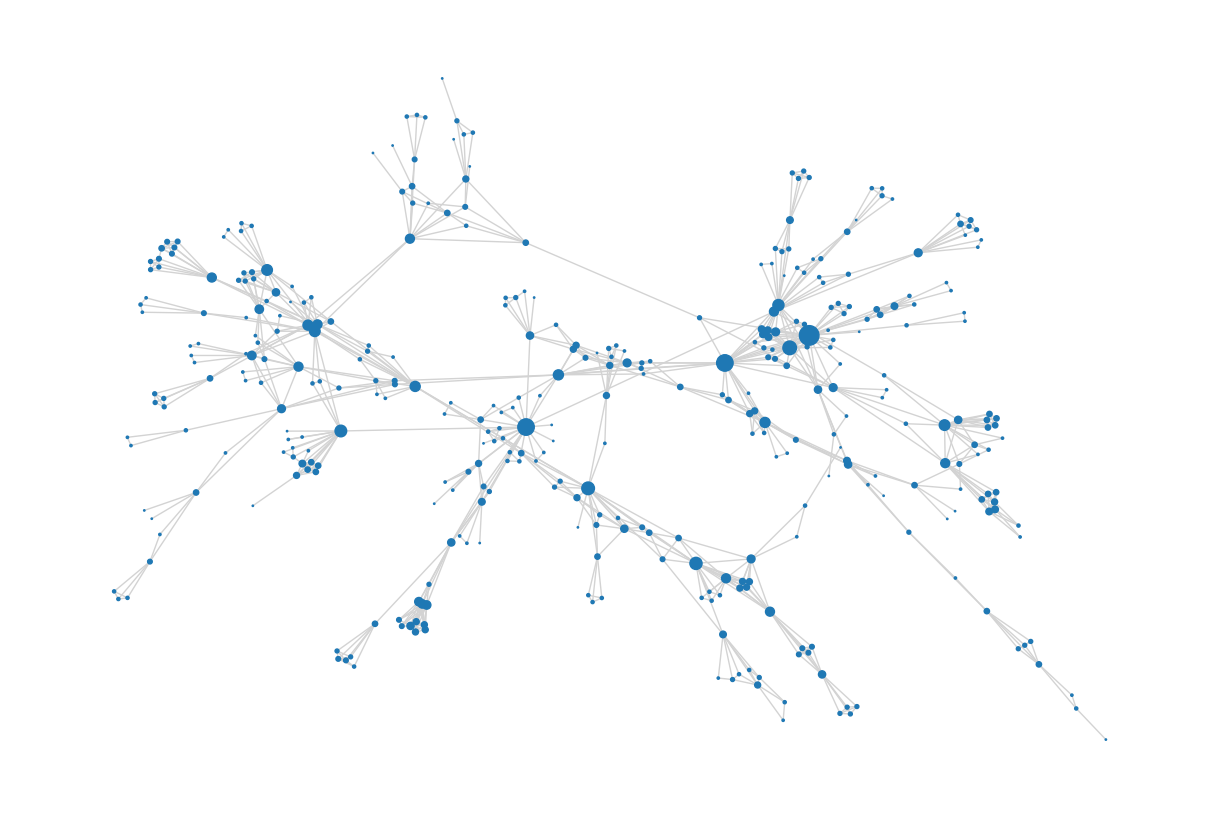

In [293]:
netscience = nx.read_gml("./netscience.gml")

seed = 867

giant = giant_subgraph(netscience)

# nx.draw_kamada_kawai(giant)

print(sorted([d[1] for d in giant.degree], reverse=True))

size = [d[1] ** 1.5 for d in giant.degree]

plt.figure(figsize=(12, 8))
nx.draw(giant, node_size=size, edge_color='lightgray')
plt.savefig("output/netscience_giant_comp.png")


3. Network Generation and Growth (30 points).

- Part I: Read Chapter 5 of Network Science, by Albert-L´aszl´o Barab´asi3 (hard copy of
textbook available in my office) on the origin of the Barab´asi-Albert network model.
(a) Write code that generates a Barab´asi-Albert network with N = 10^4 and m = 4.
Start with a fully connected 4-node network as initial condition. (Note: Various
network libraries including NetworkX in Python already have implementations of
the Barab´asi-Albert model, but you will need to implement it yourself in order
to do parts the following sub-questions.)
    
    - i. Plot the degree distribution at intermediate steps in the network’s growth.
Plot these degree distributions when the network has 10^2, 10^3, and 10^4 nodes.
    
    - ii. Compare the distributions at these intermediate steps by plotting them in a
single figure and fitting each to a power-law with degree exponent γ (include
the γ values for each distribution somewhere in the plot). Do the distributions
“converge”? Use the PLfit Python package to fit degree exponents. (extra credit -- https://github.com/network-science-data-and-models/cnet5052_sp26)

    - iii. Measure and plot the average local clustering coefficient as a function of N .
    
    - iv. Following Figure 5.6a in Chapter 5, measure the degree dynamics of one of
the initial nodes and of the nodes added to the network at times t = 100,
t = 1, 000 and t = 5, 000.

- Part II: In Section 5.9 of the textbook, we are introduced to multiple ways of gen-
erating networks with heavy-tail (scale-free) degree distributions: the Link-Selection
Model, the Copying Model, and Optimization Model.

- (b) Implement the Optimization Model.

- (c) Using your implementation of the Optimization Model, reproduce Figure 5.16b
(degree distributions when δ = 0.1, δ = 10, and δ = 1, 000) and Figure 5.16c
(visualizations of the networks at each δ value; Note: your visualizations do not
need to look exactly like the networks from the textbook, but they should capture
similar information).

- (d) Implement the Link-Selection Model and the Copying Model.

- (e) Create a figure with four subplots—inspired by the middle panel of Figure 5.16d—
that plot the preferential attachment measure Π(k) of networks sampled from each
of the following network generating models: 1) the Barab´asi-Albert model (with
N = 10, 000, m = 1), 2) the Copying Model, 3) the Link-Selection Model, 4)
the Optimization Model (with δ = 10). Note the caption of Figure 5.16: “We
used the method described in Section 5.6 to measure the preferential attachment
function. Starting from a network with N = 10, 000 nodes we added a new node
and measured the degree of the node that it connected to. We repeated this
procedure 10, 000 times, obtaining Π(k).”
(f) Describe what you observe in the figure created above.
3 https://networksciencebook.com/
3

In [203]:
def degree_distribution(G, number_of_bins=15, log_binning=True, density=True, directed=False):
    """
    Given a degree sequence, return the y values (probability) and the
    x values (support) of a degree distribution that you're going to plot.
    
    Parameters
    ----------
    G (nx.Graph):
        the network whose degree distribution to calculate

    number_of_bins (int):
        length of output vectors
    
    log_binning (bool):
        if you are plotting on a log-log axis, then this is useful
    
    density (bool):
        whether to return counts or probability density (default: True)
        Note: probability densities integrate to 1 but do not sum to 1. 

    directed (bool or str):
        if False, this assumes the network is undirected. Otherwise, the
        function requires an 'in' or 'out' as input, which will create the 
        in- or out-degree distributions, respectively.
        
    Returns
    -------
    bins_out, probs (np.ndarray):
        probability density if density=True node counts if density=False; binned edges
    
    """

    # Step 0: Do we want the directed or undirected degree distribution?
    if directed:
        if directed=='in':
            k = list(dict(G.in_degree()).values()) # get the in degree of each node
        elif directed=='out':
            k = list(dict(G.out_degree()).values()) # get the out degree of each node
        else:
            out_error = "Help! if directed!=False, the input needs to be either 'in' or 'out'"
            print(out_error)
            # Question: Is this the correct way to raise an error message in Python?
            #           See "raise" function...
            return out_error
    else:
        k = list(dict(G.degree()).values()) # get the degree of each node


    # Step 1: We will first need to define the support of our distribution
    kmax = np.max(k)    # get the maximum degree
    kmin = 0            # let's assume kmin must be 0


    # Step 2: Then we'll need to construct bins
    if log_binning:
        # array of bin edges including rightmost and leftmost
        bins = np.logspace(0, np.log10(kmax+1), number_of_bins+1)
    else:
        bins = np.linspace(0, kmax+1, num=number_of_bins+1)


    # Step 3: Then we can compute the histogram using numpy
    probs, _ = np.histogram(k, bins, density=density)


    # Step 4: Return not the "bins" but the midpoint between adjacent bin
    #         values. This is a better way to plot the distribution.
    bins_out = bins[1:] - np.diff(bins)/2.0
    
    return bins_out, probs

def degree_distribution_from_sequence(deg_seq, number_of_bins=15, log_binning=True, density=True, directed=False):
    """
    Given a degree sequence, return the y values (probability) and the
    x values (support) of a degree distribution that you're going to plot.
    
    Parameters
    ----------
    deg_seq (list):
        degree sequence for the network whose degree distribution to calculate

    number_of_bins (int):
        length of output vectors
    
    log_binning (bool):
        if you are plotting on a log-log axis, then this is useful
    
    density (bool):
        whether to return counts or probability density (default: True)
        Note: probability densities integrate to 1 but do not sum to 1. 

    directed (bool or str):
        if False, this assumes the network is undirected. Otherwise, the
        function requires an 'in' or 'out' as input, which will create the 
        in- or out-degree distributions, respectively.
        
    Returns
    -------
    bins_out, probs (np.ndarray):
        probability density if density=True node counts if density=False; binned edges
    
    """

    # # Step 0: Do we want the directed or undirected degree distribution?
    # if directed:
    #     if directed=='in':
    #         k = list(dict(G.in_degree()).values()) # get the in degree of each node
    #     elif directed=='out':
    #         k = list(dict(G.out_degree()).values()) # get the out degree of each node
    #     else:
    #         out_error = "Help! if directed!=False, the input needs to be either 'in' or 'out'"
    #         print(out_error)
    #         # Question: Is this the correct way to raise an error message in Python?
    #         #           See "raise" function...
    #         return out_error
    # else:
    #     k = list(dict(G.degree()).values()) # get the degree of each node

    k = deg_seq

    # Step 1: We will first need to define the support of our distribution
    kmax = np.max(k)    # get the maximum degree
    kmin = 0            # let's assume kmin must be 0


    # Step 2: Then we'll need to construct bins
    if log_binning:
        # array of bin edges including rightmost and leftmost
        bins = np.logspace(0, np.log10(kmax+1), number_of_bins+1)
    else:
        bins = np.linspace(0, kmax+1, num=number_of_bins+1)


    # Step 3: Then we can compute the histogram using numpy
    probs, _ = np.histogram(k, bins, density=density)


    # Step 4: Return not the "bins" but the midpoint between adjacent bin
    #         values. This is a better way to plot the distribution.
    bins_out = bins[1:] - np.diff(bins)/2.0
    
    return bins_out, probs

In [204]:
def ba_generator(n: int, m: int, init: int = 4, intermediate: list[int] = []) -> nx.Graph:
    """
    
    Parameters
    ----------
    n: int
        Number of nodes for network
    m: int
        Number of nodes each new node connects to at each step
    init: int
        Size of initial complete graph. Default: 4
    intermediate: list[int]
        Size of intermediate networks to return. Automatically includes last graph.

    Returns
    -------
    G: nx.Graph
        BA graph with size n
    Gs: list[nx.Graph]
        list of BA graphs with intermediate sizes if intermediate is not None
    
    """
    G = nx.complete_graph(init)
    Gs = []

    for i in range(init, n):
      
        if i in intermediate:
            Gs.append(G.copy())
      
        k_j = len(G.edges) * 2

        probs = [G.degree[node] / k_j for node in G.nodes]

        random_nodes = random.choices(list(G.nodes), weights=probs, k=m)

        for j in random_nodes:
            G.add_edge(i, j)
        
    if intermediate != []:
        Gs.append(G)    # add final network
        return Gs
    else:
        return G
    

def ba_node_degree_dynamics(n: int, m: int, init: int = 4, nodes: list[int] = [0]) -> list[int]:
    """
    Returns a list of the degree of nodes during network generation.
    Default is just node 0.

    Parameters
    ----------
    n: int
        Number of nodes for network
    m: int
        Number of nodes each new node connects to at each step
    init: int
        Size of initial complete graph. Default: 4
    nodes: list[int]
        Nodes to measure the degree of during network generation

    Returns
    -------
    k: pd.DataFrame
        rows: timesteps
        cols: nodes
    
    """

    k = pd.DataFrame(columns=nodes, index = range(init, n))

    G = nx.complete_graph(init)

    for i in range(init, n):

        for node in nodes:
            if i > node:
                k.loc[i, node] = G.degree(node)

      
        k_j = len(G.edges) * 2

        probs = [G.degree[node] / k_j for node in G.nodes]

        random_nodes = random.choices(list(G.nodes), weights=probs, k=m)

        for j in random_nodes:
            G.add_edge(i, j)

    return k

In [205]:
def optimization_model(n: int, delta: float) -> nx.Graph:
    """
    Creates a distance optimized network.

    Parameters
    ----------
    n: int
        Size of network to be generated

    delta: float
        parameter

    Returns
    -------
    G: nx.Graph
        Network generated with optimization model   

    """        

    G = nx.Graph()

    node_positions = np.random.rand(n, 2)

    G.add_node(0, pos=(node_positions[0]))

    for i in range(1, n):
        positions = node_positions[:i] # existing node positions
        pos = node_positions[i] # current node position

        euclidean_distances = [math.dist(pos, p) * delta for p in positions]

        path_distances = list(nx.single_source_shortest_path_length(G, 0).values())

        distances = np.array(euclidean_distances) + np.array(path_distances)
        
        G.add_node(i, pos=(pos))
        G.add_edge(i, np.argmin(distances))

    return G


In [206]:
def link_selection_model(n: int) -> nx.Graph:
    """
    Implements link selection model, n >= 2

    Parameters
    ----------
    n: int
        Size of network to be created

    Returns
    -------
    G: nx.Graph
        Network generated with link selection model
    
    """

    G = nx.Graph()
    G.add_edge(0, 1)

    for i in range(2, n):

        random_edge = random.choice([edge for edge in G.edges])
        random_node = random.choice(random_edge)

        G.add_edge(i, random_node)

    return G


In [207]:
def copying_model(n: int, p: float) -> nx.DiGraph:

    """
    Implements copying selection model

    Parameters
    ----------
    n: int
        Size of network to be created
    p: float
        Probability of connecting new node to random node; connects to random nodes child 
        with probability (p - 1)

    Returns
    -------
    G: nx.Graph
        Network generated with copying model
    
    """

    G = nx.DiGraph()

    G.add_edge(0, 1)

    for i in range(2, n):

        random_node = random.choice([node for node in G.nodes])

        if p < random.random() or len(nx.descendants(G, random_node)) == 0:
            G.add_edge(i, random_node)
        else:
            G.add_edge(i, list(nx.descendants(G, random_node))[0])


    return G


In [213]:
Gs = ba_generator(10000, 4, intermediate=[10 ** 2, 10 ** 3, 10 ** 4])

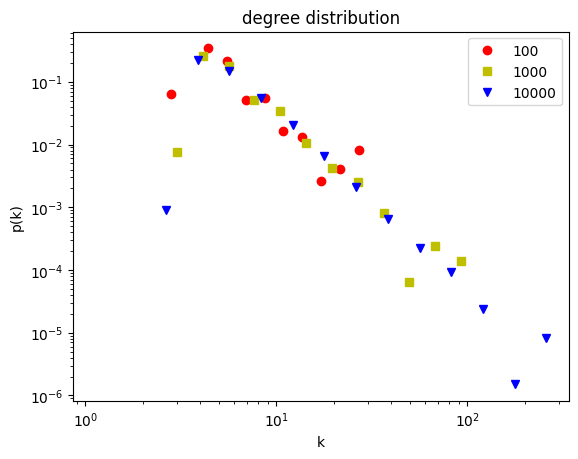

In [366]:
x, y = degree_distribution(Gs[0])
plt.loglog(x, y, 'ro', label=str(len(Gs[0])))

x, y = degree_distribution(Gs[1])
plt.loglog(x, y, 'ys', label=str(len(Gs[1])))

x, y = degree_distribution(Gs[2])
plt.loglog(x, y, 'bv', label=str(len(Gs[2])))

plt.xscale("log")
plt.title("degree distribution")
plt.xlabel("k")
plt.ylabel("p(k)")
plt.legend()

# plt.show()
plt.savefig("output/ba_deg_dist.png")


In [314]:
Gs2 = ba_generator(10000, 4, intermediate=[0, 10, 20, 40, 100, 200, 400, 1000, 2000, 4000, 10000])
print(Gs2)

[<networkx.classes.graph.Graph object at 0x7dffe55d16d0>, <networkx.classes.graph.Graph object at 0x7dffe55d0f80>, <networkx.classes.graph.Graph object at 0x7dffe55d30b0>, <networkx.classes.graph.Graph object at 0x7dffe55d1010>, <networkx.classes.graph.Graph object at 0x7dfff017bad0>, <networkx.classes.graph.Graph object at 0x7dfff017b0b0>, <networkx.classes.graph.Graph object at 0x7dffef613530>, <networkx.classes.graph.Graph object at 0x7e00229b22a0>, <networkx.classes.graph.Graph object at 0x7dffef7cc320>, <networkx.classes.graph.Graph object at 0x7e0020180c20>]


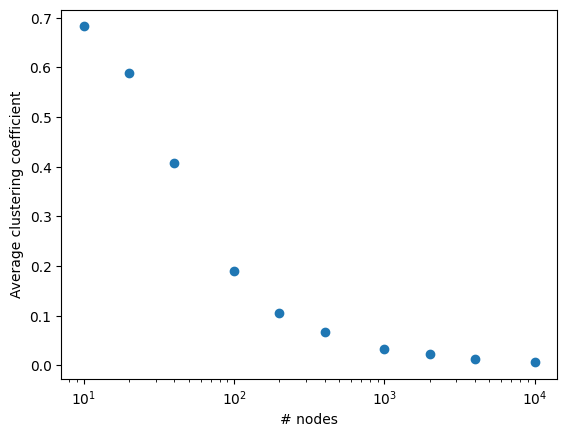

In [323]:
c = []
x = [len(G) for G in Gs2]

for G in Gs2:
    c.append(nx.average_clustering(G))

plt.plot(x, c, 'o')
plt.xscale("log")
plt.xlabel("# nodes")
plt.ylabel("Average clustering coefficient")

plt.savefig("output/ba_avg_clustering.png")

In [325]:
nodes = [0, 100, 1000, 5000]
df = ba_node_degree_dynamics(10000, 4, 4, nodes)

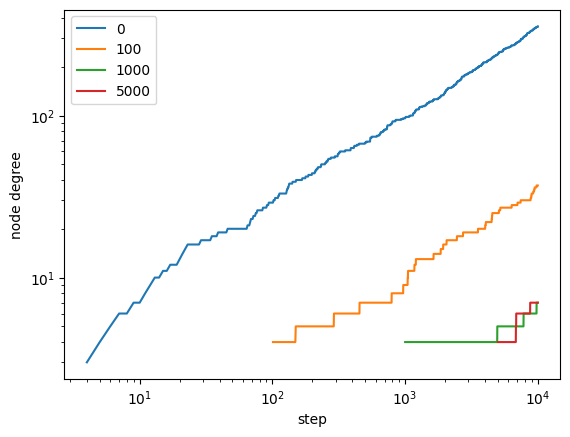

In [326]:
plt.loglog(df, label=df.columns)
plt.xlabel("step")
plt.ylabel("node degree")
plt.legend()
# plt.show()
plt.savefig("output/ba_node_degree_dynamics.png")

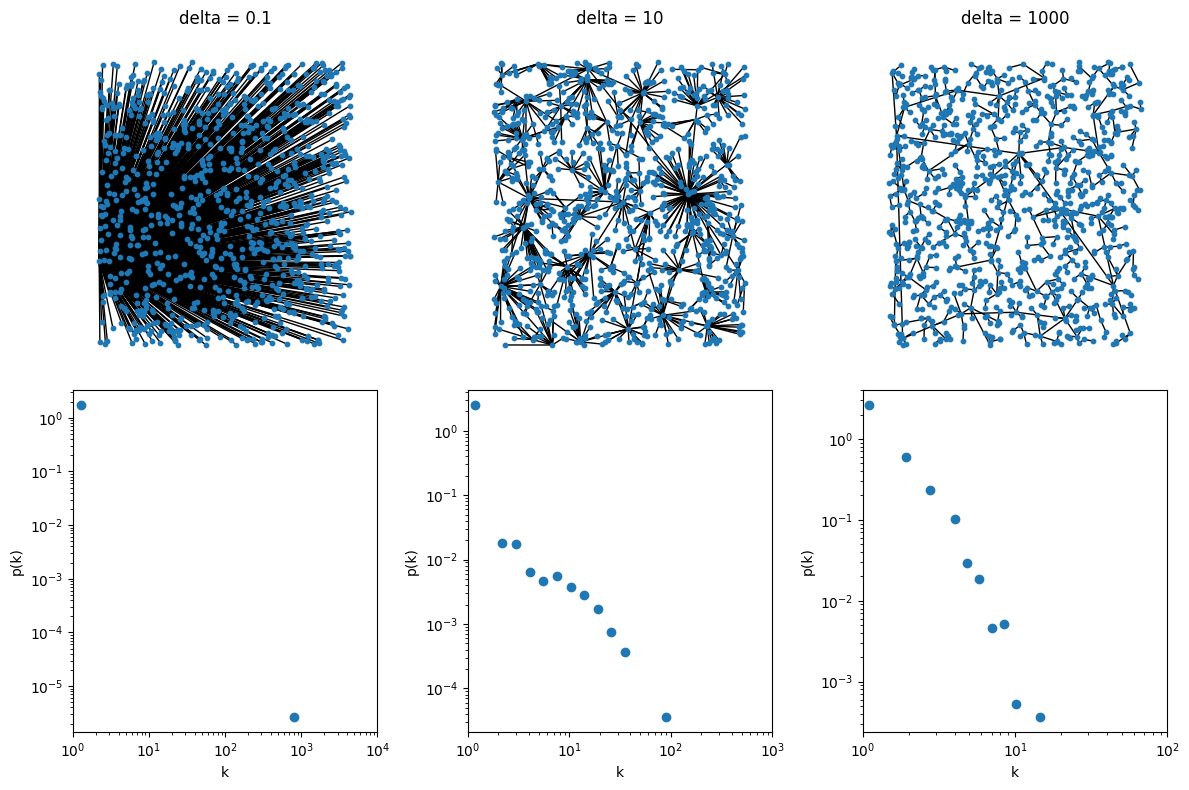

In [416]:
n1 = 1000
n2 = 1000
deltas = [0.1, 10, 1000]

fix, ax = plt.subplots(nrows=2, ncols=len(deltas), figsize=(12, 8))



# figure (b)
for i, delta in enumerate(deltas):

    G = optimization_model(n=n1, delta=delta)

    pos = {}
    for node in G.nodes:
        pos[node] = G.nodes[node]["pos"]
    
    ax[0, i].set_title(f"delta = {delta}")

    nx.draw(G, pos=pos, node_size=10, ax=ax[0, i])


# figure (c)
for i, delta in enumerate(deltas):

    G = optimization_model(n=n2, delta=delta)

    x, y = degree_distribution(G)
    
    # print(i, x, y)
    ax[1, i].loglog(x, y, 'o')
    ax[1, i].set_xbound(10 ** 0, 10 ** (4 - i))
    ax[1, i].set_ylabel("p(k)")
    ax[1, i].set_xlabel("k")


plt.tight_layout()
# plt.show()
plt.savefig("output/optimization_model.png")


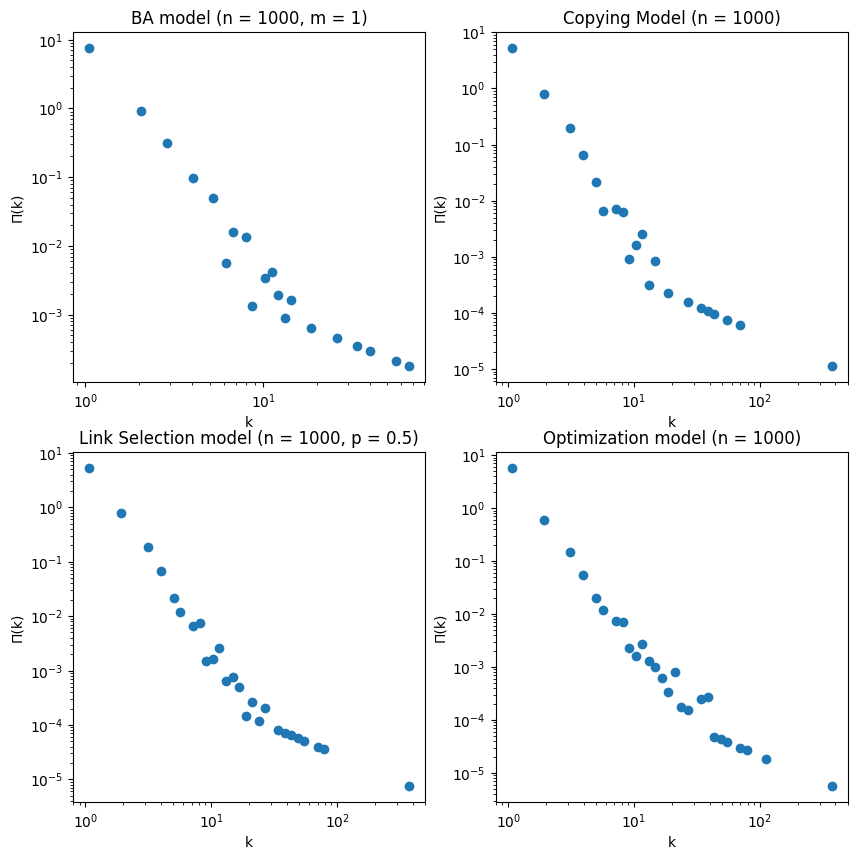

In [411]:
num_graphs = 10

n = 1000
m = 1
p = 0.5
delta = 10

funcs = [ba_generator(n,m), copying_model(n, 0.5), link_selection_model(n), optimization_model(n, delta)]
titles = [f"BA model (n = {n}, m = {m})", f"Copying Model (n = {n})", f"Link Selection model (n = {n}, p = {p})", f"Optimization model (n = {n})"]
plots = [(0, 0), (0, 1), (1, 0), (1, 1)]


fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

deg_seq = []

for i, func in enumerate(funcs):
    for _ in range(num_graphs):
        G = func
        deg_seq += [G.degree[node] for node in G.nodes]

    x, y = degree_distribution_from_sequence(deg_seq, number_of_bins=50)

    ax[plots[i]].loglog(x, y, 'o')
    ax[plots[i]].set_title(titles[i])
    ax[plots[i]].set_xlabel("k")
    ax[plots[i]].set_ylabel("Π(k)")

plt.savefig("output/pref_att_measure.png")



4. Graph Distance Measures (25 points).
Create a graph distance measure, or implement one that you found in the literature.

- (a) Describe the graph descriptor, ϕ(G), you use in your distance measure. Justify
why this is a good descriptor to use.

- (b) Describe the distance measure you use to quantify dissimilarity between pairs of
graphs, G1 and G2.

- (c) Implement your graph distance in two functions: the first function should compute
the ϕ(G) for an input graph, G, and the second function should call the first in
order to output the final distance value. For example, if your graph distance was
the Degree Divergence, your descriptor ϕ(G) would be a function that takes a
graph as input and outputs the degree distribution of G. Your distance function
would then take two graphs as input, create a ϕ(G1) and ϕ(G2), and calculate the
distance d(ϕ(G1), ϕ(G2)). You may not use the Deg. Div. as your graph distance.

- (d) For 1,000 iterations, sample pairs of Erd˝os-R´enyi graphs with N = 500 nodes and
p = 0.016. Calculate and store the graph distance between each pair. Plot the
distribution of distance values between the ER networks.

- (e) For 1,000 iterations, sample pairs of Barab´asi-Albert graphs with N = 500 nodes
and m = 4. Calculate and store the graph distance between each pair. Plot the
distribution of distance values between the BA networks.

- (f) For 1,000 iterations, using the same parameterizations above, sample one ER
and one BA graph, and compute and store the distance between them. Neatly
visualize all three distributions on the same plot, with appropriate legends and
color. What do you notice?


In [ ]:
import warnings

def phi(G: nx.Graph) -> list[float, float]:

    clustering = nx.average_clustering(G)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        assortativity = nx.degree_assortativity_coefficient(G)

        if np.isnan(assortativity):
            assortativity = 1.0

    return np.array([clustering, assortativity])



def d(G1, G2):
    return np.linalg.norm(phi(G1) - phi(G2))


In [408]:
n = 500
p = 0.016
m = 4

iters = range(150)
graphs = ["er_er", "ba_ba", "ba_er"]

df = pd.DataFrame(index=iters, columns=graphs)

for i in iters:
    er1 = nx.erdos_renyi_graph(n, p)
    er2 = nx.erdos_renyi_graph(n, p)
    ba1 = nx.barabasi_albert_graph(n, m)
    ba2 = nx.barabasi_albert_graph(n, m)

    df.loc[i, "er_er"] = d(er1, er2)
    df.loc[i, "ba_ba"] = d(ba1, ba2)
    df.loc[i, "ba_er"] = d(ba1, er1)

print(df)


        er_er     ba_ba     ba_er
0    0.019619  0.008084  0.100853
1    0.049438  0.007594  0.051027
2    0.013056  0.015791  0.139005
3    0.041814  0.033963  0.145412
4    0.019456  0.018879  0.050679
..        ...       ...       ...
145  0.020692  0.026079  0.066232
146  0.057276  0.020912  0.136555
147  0.010073  0.031954  0.112547
148  0.019061  0.027102  0.075978
149  0.007156  0.027086  0.114592

[150 rows x 3 columns]


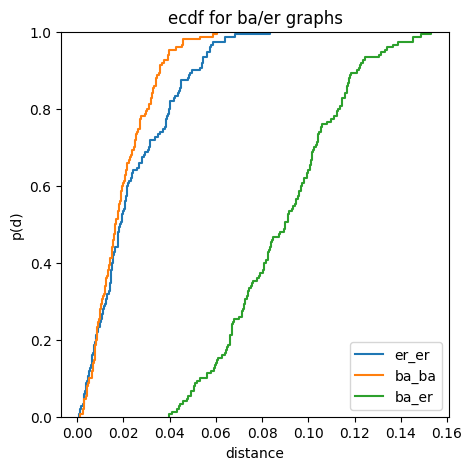

In [409]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

for i, graph in enumerate(graphs):
    ax.ecdf(df[graph].astype(float), label=graph)

ax.set_title("ecdf for ba/er graphs")
ax.set_ylabel("p(d)")
ax.set_xlabel("distance")

plt.legend()
# plt.show()
plt.savefig("output/ba_er_ecdf.png")

5. Sparsification & Robustness (15 points).
A classic intuition in network science is that heavy-tailed networks are robust to ran-
dom failures but fragile to targeted attacks because of hubs. For each ensemble below,
generate graphs with N = 5, 000 nodes and approximately the same expected mean
degree ⟨k⟩ ≈ 10:

• Erd˝os-R´enyi: G(N, p) with p chosen such that ⟨k⟩ ≈ 10.

• Barab´asi-Albert: preferential attachment with m chosen so ⟨k⟩ ≈ 10.

• Random regular: a random d-regular graph with d = 10.

For each ensemble, generate at least 10 independent graph realizations (using different
random seeds) and average results across realizations.

- (a) For each graph, simulate the following node removal from the network (i.e., delete
the node and all of its incident edges):

    - (i) Randomly: remove a fraction f of nodes uniformly at random, or

    - (ii) Targeted: remove a fraction f of nodes in descending order of degree.

For each of these simulations, use f ∈ {0.00, 0.02, 0.04, . . . , 0.40}.
4

- (b) After each removal, compute
S(f ) = size of the largest connected component after removal
N .
Plot S(f ) versus f for each ensemble, with two curves per ensemble (random
failure vs. targeted attack). Include uncertainty across realizations (e.g. shaded
±1 standard deviation or error bars at selected values of f ).

- (c) In a few sentences, discuss your findings and observations.

Spent way too long finding out that removing nodes completely randomly and iteratively randomly does basically the same thing 
because I didn't believe the results for basically the exact same behavior in all of the graphs.


In [361]:
def remove_random_nodes(G: nx.Graph, f: float) -> nx.Graph:
    """
    Returns a copy of a graph with a random fraction (f) of nodes removed from a graph.

    Parameters
    ----------
    G: nx.Graph
        Graph to remove nodes
    f: float
        Fraction of nodes to remove

    Returns
    -------
    G_copy: nx.Graph
        Copy of graph with random nodes removed

    """

    G = G.copy()

    nodes_to_remove = int(len(G) * f)

    for _ in range(nodes_to_remove):
        G.remove_node(random.choice([node for node in G.nodes]))

    return G

def remove_random_nodes_in_order(G: nx.Graph, f: list[float]) -> list[nx.Graph]:
    """
    Removes proportions of random nodes from a graph, with each iteration only removing
    the difference between previous and current iteration.
    
    ex. len(G) = 100; f = [0.2, 0.4]; removes 20 nodes, then 20 more nodes.

    Returns a list of graphs.
    
    """

    G_size = len(G)
    G = G.copy()

    nodes_to_remove = []
    subgraphs = []

    for i in range(len(f)):
        k = int((G_size * f[i]) - len(nodes_to_remove))  # difference in proportion of nodes from last removal
        
        nodes_to_remove += random.choices([node for node in G.nodes], k=k)

        G.remove_nodes_from(nodes_to_remove)

        subgraphs.append(G.copy())

    # for subgraph in subgraphs:
    #     print(subgraph)

    return subgraphs


def remove_highest_degree_nodes(G: nx.Graph, f: float) -> nx.Graph:
    """
    Returns a copy of a graph with a fraction (f) of highest degree nodes removed from a graph.

    Parameters
    ----------
    G: nx.Graph
        Graph to remove nodes
    f: float
        Fraction of nodes to remove

    Returns
    -------
    G_copy: nx.Graph
        Copy of graph with higest degree nodes removed

    """

    G = G.copy()

    degrees = dict(G.degree)

    highest_degrees = dict(sorted(degrees.items(), key=lambda item: item[1], reverse=True))

    nodes_to_remove = list(highest_degrees)[:int(len(G) * f)]

    G.remove_nodes_from(nodes_to_remove)

    return G





In [364]:
n = 5000

iters = 10
fractions = np.arange(0.0, 0.42, 0.02)


#
#   ER graphs
#

p = 10 / (n - 1) # <k> ~ 10

er_highest = pd.DataFrame(index=fractions, columns=range(iters))
er_random = pd.DataFrame(index=fractions, columns=range(iters))

for i in range(iters):

    # Generate ER graph
    G = nx.erdos_renyi_graph(n, p)

    for f in fractions:

        G_highest = remove_highest_degree_nodes(G, f)
        G_highest_lcc = max([len(c) for c in nx.connected_components(G_highest)])

        er_highest.loc[f, i] = G_highest_lcc / n

        # G_rand = remove_random_nodes(G, f)
        # G_rand_lcc = max([len(c) for c in nx.connected_components(G_rand)])

        # er_random.loc[f, i] = G_rand_lcc

    G_rands = remove_random_nodes_in_order(G, fractions)

    for j in range(len(fractions)):
        G_random_lcc = max([len(c) for c in nx.connected_components(G_rands[j])])

        er_random.loc[fractions[j], i] = G_random_lcc / n


#
#   BA graphs
#

m = 5

ba_highest = pd.DataFrame(index=fractions, columns=range(iters))
ba_random = pd.DataFrame(index=fractions, columns=range(iters))

for i in range(iters):

    G = nx.barabasi_albert_graph(n, m)

    for f in fractions:

        G_highest = remove_highest_degree_nodes(G, f)
        G_highest_lcc = max([len(c) for c in nx.connected_components(G_highest)])

        ba_highest.loc[f, i] = G_highest_lcc / n


    G_rands = remove_random_nodes_in_order(G, fractions)

    for j in range(len(fractions)):
        G_random_lcc = max([len(c) for c in nx.connected_components(G_rands[j])])

        ba_random.loc[fractions[j], i] = G_random_lcc / n


#
#   d-regular graphs
#

d = 10

dr_highest = pd.DataFrame(index=fractions, columns=range(iters))
dr_random = pd.DataFrame(index=fractions, columns=range(iters))

for i in range(iters):

    G = nx.random_regular_graph(d, n)

    for f in fractions:

        G_highest = remove_highest_degree_nodes(G, f)
        G_highest_lcc = max([len(c) for c in nx.connected_components(G_highest)])

        dr_highest.loc[f, i] = G_highest_lcc / n

        # G_rand = remove_random_nodes(G, f)
        # G_rand_lcc = max([len(c) for c in nx.connected_components(G_rand)])

        # dr_random.loc[f, i] = G_rand_lcc

    

    G_rands = remove_random_nodes_in_order(G, fractions)

    for j in range(len(fractions)):
        G_random_lcc = max([len(c) for c in nx.connected_components(G_rands[j])])

        dr_random.loc[fractions[j], i] = G_random_lcc / n





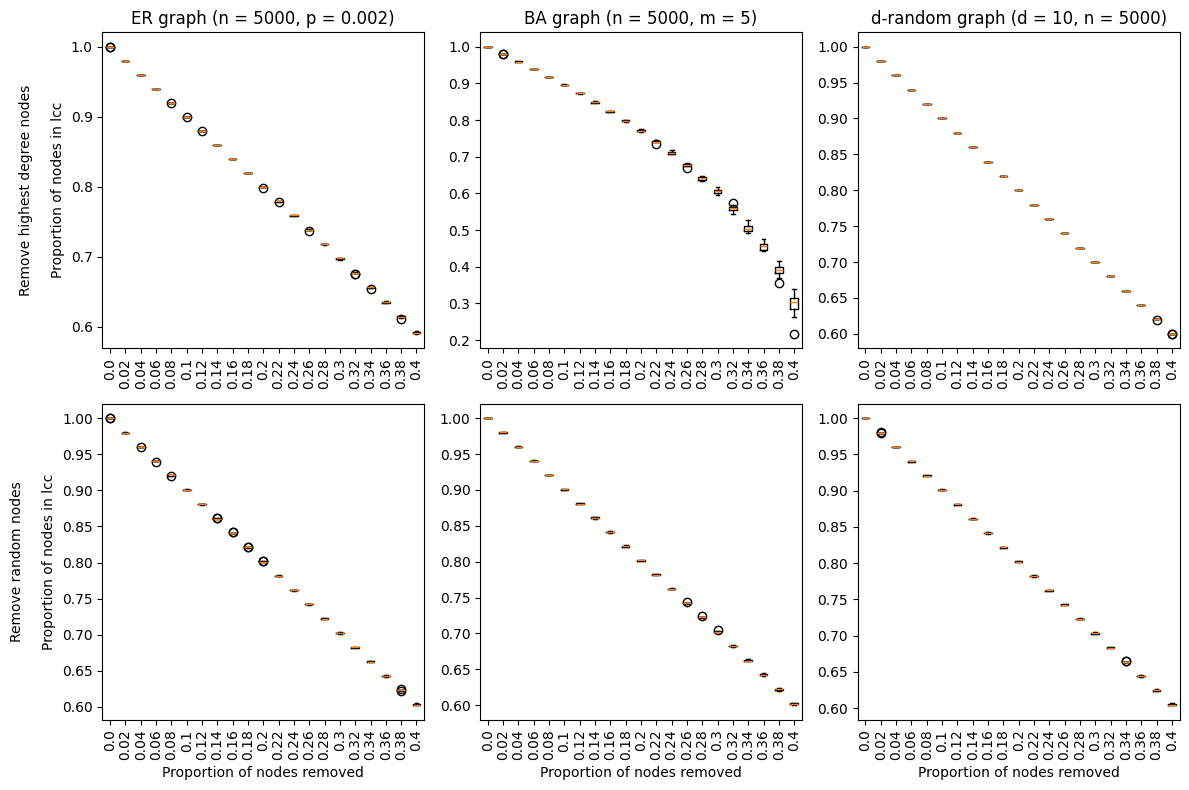

In [365]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))

ax[0, 0].boxplot(er_highest.T)
ax[0, 0].set_xticklabels(fractions, rotation=90)
ax[0, 0].set_title(f"ER graph (n = {n}, p = {p.__round__(3)})")
ax[0, 0].set_ylabel("Remove highest degree nodes\n\nProportion of nodes in lcc")
ax[1, 0].boxplot(er_random.T)
ax[1, 0].set_xticklabels(fractions, rotation=90)
ax[1, 0].set_ylabel("Remove random nodes\n\nProportion of nodes in lcc")


ax[0, 1].boxplot(ba_highest.T)
ax[0, 1].set_xticklabels(fractions, rotation=90)
ax[0, 1].set_title(f"BA graph (n = {n}, m = {m})")
ax[1, 1].boxplot(ba_random.T)
ax[1, 1].set_xticklabels(fractions, rotation=90)


ax[0, 2].boxplot(dr_highest.T)
ax[0, 2].set_xticklabels(fractions, rotation=90)
ax[0, 2].set_title(f"d-random graph (d = {d}, n = {n})")
ax[1, 2].boxplot(dr_random.T)
ax[1, 2].set_xticklabels(fractions, rotation=90)


ax[1, 0].set_xlabel("Proportion of nodes removed")
ax[1, 1].set_xlabel("Proportion of nodes removed")
ax[1, 2].set_xlabel("Proportion of nodes removed")



plt.tight_layout()

# plt.show()
plt.savefig("output/targeted_random_removal.png")